In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tawfikelmetwally/automobile-dataset")

print("Path to dataset files:", path)

100%|██████████| 6.45k/6.45k [00:00<00:00, 10.9MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/tawfikelmetwally/automobile-dataset/versions/1


In [8]:
import pandas as pd
import glob


csv_files = glob.glob(f'{path}/*.csv')

if csv_files:
    df = pd.read_csv(csv_files[0])
    print(f"Carga existosa {csv_files[0]} en el DataFrame.")
    display(df.head())
else:
    print("No se encontraron archivos CSV en path.")

Carga existosa /root/.cache/kagglehub/datasets/tawfikelmetwally/automobile-dataset/versions/1/Automobile.csv en el DataFrame.


,name,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,chevrolet chevelle malibu,18.0,8,307.0,130.0,3504,12.0,70,usa
1,buick skylark 320,15.0,8,350.0,165.0,3693,11.5,70,usa
2,plymouth satellite,18.0,8,318.0,150.0,3436,11.0,70,usa
3,amc rebel sst,16.0,8,304.0,150.0,3433,12.0,70,usa
4,ford torino,17.0,8,302.0,140.0,3449,10.5,70,usa


Carga de datos en el data frame

## Visualización de Datos

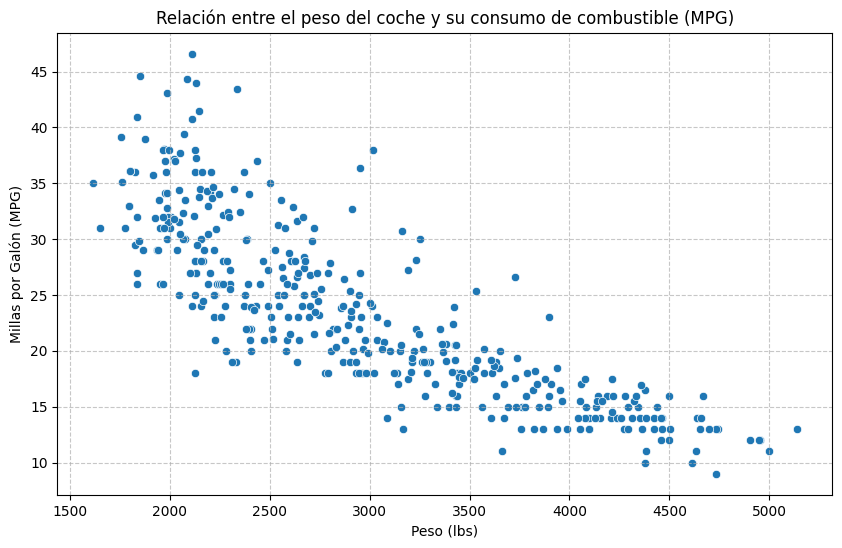

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Gráfico de dispersión para mpg y weight
plt.figure(figsize=(10, 6))
sns.scatterplot(x='weight', y='mpg', data=df)
plt.title('Relación entre el peso del coche y su consumo de combustible (MPG)')
plt.xlabel('Peso (lbs)')
plt.ylabel('Millas por Galón (MPG)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Relación entre el peso del automovil y el consumo. Mintras mas peso menos galones por milla, o sea mas consumo.

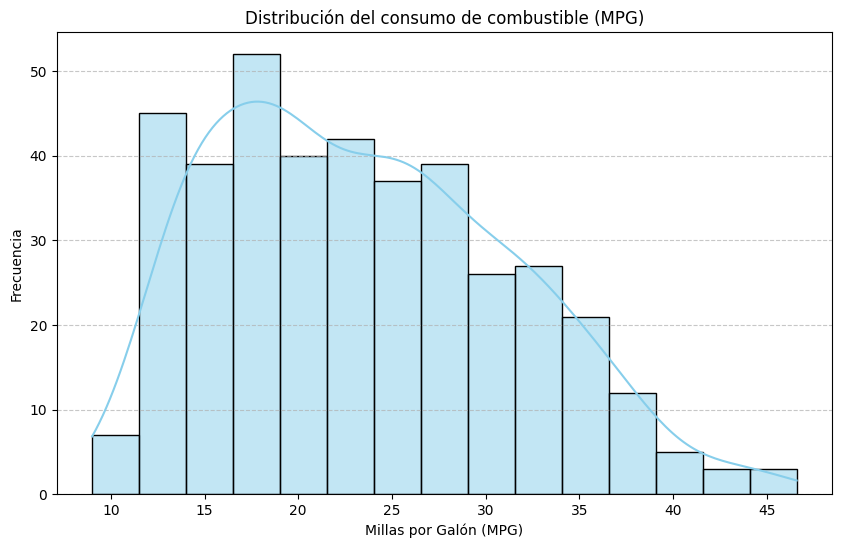

In [5]:
# 3. Histograma del consumo de combustible (mpg)
plt.figure(figsize=(10, 6))
sns.histplot(df['mpg'], kde=True, bins=15, color='skyblue')
plt.title('Distribución del consumo de combustible (MPG)')
plt.xlabel('Millas por Galón (MPG)')
plt.ylabel('Frecuencia')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Consumo de combustible por galón

/tmp/ipykernel_1871/4136702302.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cylinders', y='mpg', data=df, palette='viridis')


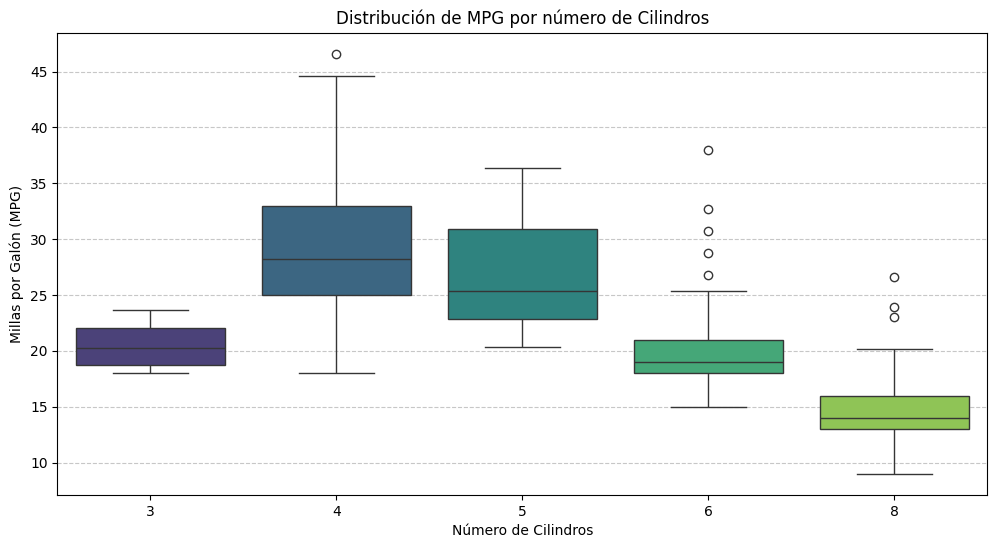

/tmp/ipykernel_1871/4136702302.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='origin', y='mpg', data=df, palette='plasma')


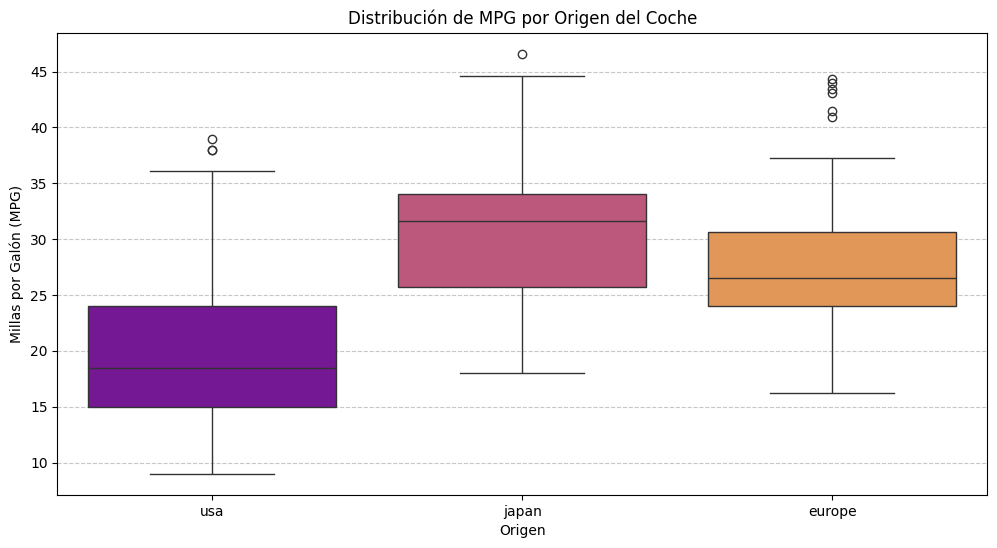

In [6]:
# 4. Diagrama de caja (boxplot) de las características cylinders y origin contra mpg

# Boxplot para 'cylinders' vs 'mpg'
plt.figure(figsize=(12, 6))
sns.boxplot(x='cylinders', y='mpg', data=df, palette='viridis')
plt.title('Distribución de MPG por número de Cilindros')
plt.xlabel('Número de Cilindros')
plt.ylabel('Millas por Galón (MPG)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Boxplot para 'origin' vs 'mpg'
plt.figure(figsize=(12, 6))
sns.boxplot(x='origin', y='mpg', data=df, palette='plasma')
plt.title('Distribución de MPG por Origen del Coche')
plt.xlabel('Origen')
plt.ylabel('Millas por Galón (MPG)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Se observan valores atítpicos en los automóviles de los tres paises.

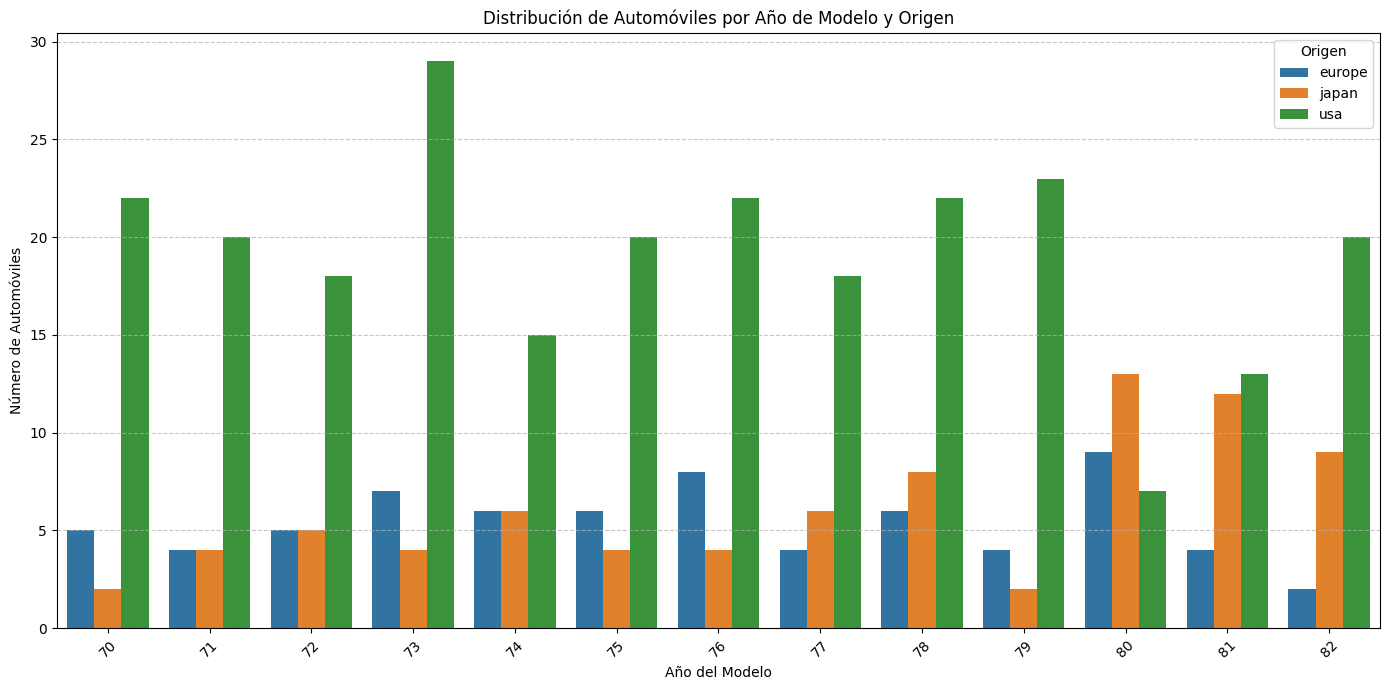

In [7]:
# 5. Gráfico de barras que muestre la distribución de automóviles según su año de modelo (model_year) y origen (origin)

# Contar la ocurrencia de cada combinación de model_year y origin
distribution_data = df.groupby(['model_year', 'origin']).size().reset_index(name='count')

plt.figure(figsize=(14, 7))
sns.barplot(x='model_year', y='count', hue='origin', data=distribution_data, palette='tab10')
plt.title('Distribución de Automóviles por Año de Modelo y Origen')
plt.xlabel('Año del Modelo')
plt.ylabel('Número de Automóviles')
plt.legend(title='Origen')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45) # Rotar las etiquetas del eje x para mejor legibilidad
plt.tight_layout()
plt.show()

Este gráfico da una idea de la evolución de los modelos en los años y su origen